In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from genkit import DLPMEps, GaussianFlowLinear, TEDMOrigin
from genkit.datasets import fetch_synthetic_data, fetch_real_data, get_dataset_metadata, list_datasets
from genkit.inspect import estimate_init_error, estimate_training_loss_error, model_est_err_curve, model_est_jacobian_spectral_curve
from genkit.metrics import mmd_rbf, sliced_wasserstein, tail_coverage_error
from genkit.nn import MLPModel
from genkit.training import train
from labkit.report import format_mean_std_latex, summarize_metric_values, PRETTY_RCPARAMS

plt.rcParams.update(PRETTY_RCPARAMS)


/home/hcherkaoui/src/flowbench/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def plot_band(ax, mean, std=None, *, color, linestyle="solid", lw=2.0, alpha=0.6, fill_alpha=0.1, label=None, marker=None, lower_clip=None, x_values=None):
    mean = np.asarray(mean, dtype=float)
    if mean.size == 0 or np.all(~np.isfinite(mean)):
        return
    x_values = np.arange(len(mean)) if x_values is None else np.asarray(x_values)
    if lower_clip is not None:
        mean = np.maximum(mean, float(lower_clip))
    plot_kwargs = {"color": color, "linestyle": linestyle, "lw": lw, "alpha": alpha}
    if label is not None:
        plot_kwargs["label"] = label
    if marker is not None:
        plot_kwargs["marker"] = marker
    ax.plot(x_values, mean, **plot_kwargs)
    if std is None:
        return
    std = np.asarray(std, dtype=float)
    if std.shape != mean.shape or np.all(~np.isfinite(std)):
        return
    lower = mean - std
    upper = mean + std
    if lower_clip is not None:
        lower = np.maximum(lower, float(lower_clip))
        upper = np.maximum(upper, float(lower_clip))
    ax.fill_between(x_values, lower, upper, color=color, alpha=fill_alpha)


def render_dataframe_table(ax, frame, *, col_labels=None, fontsize=8.5, scale=(1.0, 1.35)):
    ax.axis("off")
    table = ax.table(cellText=frame.values, rowLabels=frame.index, colLabels=list(frame.columns) if col_labels is None else list(col_labels), loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(*scale)
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("0.2")
        cell.set_linewidth(0.6)
        if row == 0 or col == -1:
            cell.set_text_props(weight="bold")
    return table


def summarize_metric_frame(df, metric_names, source_order):
    rows = []
    for model_name in source_order:
        model_df = df[df["model"] == model_name]
        row = {"model": model_name}
        for metric_name in metric_names:
            stats = summarize_metric_values(model_df[metric_name].tolist())
            row[metric_name] = stats["mean"]
            row[f"{metric_name}_std"] = stats["std"]
        rows.append(row)
    return pd.DataFrame(rows).set_index("model").loc[source_order]


def summarize_nested_metric_frame(df, metric_names, source_order):
    rows = []
    for model_name in source_order:
        model_df = df[df["model"] == model_name]
        row = {"model": model_name}
        for metric_name in metric_names:
            row[metric_name] = summarize_metric_values(model_df[metric_name].tolist())
        rows.append(row)
    return pd.DataFrame(rows).set_index("model").loc[source_order]


def format_mean_std_table(summary_df, metric_names, *, best_by_metric=None):
    table = pd.DataFrame(index=summary_df.index, columns=list(metric_names), dtype=object)
    best_by_metric = {} if best_by_metric is None else dict(best_by_metric)
    for metric_name in metric_names:
        best_model = None
        if best_by_metric.get(metric_name) == "min":
            best_model = summary_df[metric_name].idxmin()
        elif best_by_metric.get(metric_name) == "max":
            best_model = summary_df[metric_name].idxmax()
        for model_name in summary_df.index:
            table.loc[model_name, metric_name] = format_mean_std_latex(summary_df.loc[model_name, metric_name], summary_df.loc[model_name, f"{metric_name}_std"], bold=model_name == best_model)
    return table


def safe_inspect_scalar(model, fn, *args, **kwargs):
    if getattr(model, "_family", None) == "vendor":
        return float("nan")
    return float(fn(model, *args, **kwargs))


def safe_inspect_curve(model, fn, *args, length, **kwargs):
    if getattr(model, "_family", None) == "vendor":
        return np.full(int(length), np.nan, dtype=float)
    return np.asarray(fn(model, *args, **kwargs), dtype=float)


def format_mean_std_or_na(stats, *, bold=False):
    mean = float(stats["mean"])
    std = float(stats["std"])
    if not np.isfinite(mean):
        return "N/A"
    if not np.isfinite(std):
        std = 0.0
    return format_mean_std_latex(max(0.0, mean), std, bold=bold)


def first_curve_length(curve_map):
    for curves in curve_map.values():
        if curves:
            return int(np.asarray(curves[0], dtype=float).shape[0])
    return 0


In [3]:
for ds in list_datasets():
    print(get_dataset_metadata(ds))

{'name': 'alpha_stable', 'tail_index_alpha': 'configurable', 'description': 'Isotropic alpha-stable synthetic dataset.', 'split_mode': 'random', 'dataset_type': 'synthetic', 'dim': None, 'n_samples': None}
{'name': 'balanced_bimodal_gaussian', 'tail_index_alpha': None, 'description': 'Balanced bimodal Gaussian synthetic dataset.', 'split_mode': 'random', 'dataset_type': 'synthetic', 'dim': None, 'n_samples': None}
{'name': 'checker', 'tail_index_alpha': None, 'description': 'Checkerboard synthetic dataset.', 'split_mode': 'random', 'dataset_type': 'synthetic', 'dim': 2, 'n_samples': None}
{'name': 'default_credit', 'tail_index_alpha': None, 'description': 'Default of Credit Card Clients dataset from OpenML.', 'split_mode': 'random', 'dataset_type': 'real', 'dim': None, 'n_samples': None}
{'name': 'earthquakes', 'tail_index_alpha': None, 'description': 'Earthquake magnitude benchmark from the Clauset collection.', 'split_mode': 'random', 'dataset_type': 'real', 'dim': 1, 'n_samples': No

In [ ]:
# dataset
n_samples = 30_000
val_size = 0.0001
test_size = 0.2

# nets
depth = 3
width = 128
time_dim = 32

# models
n_steps = 128

# training
grad_clip_norm = 5.0
n_epochs = 256
use_adamw = True
num_workers = 0

# general
n_trials = 2
device = "cpu"
fdtype = torch.float64
idtype = torch.int64

# declare models
model_specs = [
    {"name": "DLPM-E",
     "cls": DLPMEps,
     "source_distri": "Alpha-stable",
     "extra_kwargs": {"alpha": 1.7, "n_trial_A": 1},
     "train_kwargs": {"lr": 5e-4, "batch_size": 1024, "n_epochs": n_epochs, "grad_clip_norm": grad_clip_norm},
     "color": "tab:orange",
     "linestyle": "dotted",
     "marker": "^",
     },
    {"name": "TEDM-Orig",
     "cls": TEDMOrigin,
     "source_distri": "Student-t",
     "extra_kwargs": {"nu": 2.1, "sigma_min": 0.01, "sigma_max": 4.0},
     "train_kwargs": { "lr": 5e-4, "batch_size": 1024, "n_epochs": n_epochs, "grad_clip_norm": grad_clip_norm},
     "color": "tab:green",
     "linestyle": "dashdot",
     "marker": "D",
     },
    {"name": "GF-Linear",
     "cls": GaussianFlowLinear,
     "source_distri": "Gaussian",
     "extra_kwargs": {},
     "train_kwargs": {"lr": 5e-4, "batch_size": 2048, "n_epochs": n_epochs, "grad_clip_norm": grad_clip_norm},
     "color": "tab:blue",
     "linestyle": "solid",
     "marker": "s",
     },
]


In [5]:
runs = []
with tqdm(total=n_trials * len(model_specs), initial=0, desc="Training models") as pbar:

    for trial_idx in range(n_trials):

        x_train, _, x_ref = fetch_synthetic_data("alpha_stable", n_samples=n_samples, val_size=val_size, test_size=test_size, dim=10, device=device, dtype=fdtype)

        for spec in model_specs:

            net = MLPModel(input_dim=x_train.shape[1], output_dim=x_train.shape[1], width=width, depth=depth, time_dim=time_dim)
            generator = spec["cls"](net=net.to(device=device, dtype=fdtype), dim=x_train.shape[1], n_steps=n_steps, device=device, fdtype=fdtype, idtype=idtype, **spec["extra_kwargs"])

            train(generative_model=generator, target_data=x_train.clone(), use_adamw=use_adamw, num_workers=num_workers, device=device, **spec.get("train_kwargs", {}))

            runs.append({"trial_idx": trial_idx, "x_ref": x_ref.clone(), "model": spec["name"], "generator": generator})
            pbar.update(1)


Training models: 100%|██████████| 6/6 [03:39<00:00, 36.58s/it]


In [6]:
source_order = [spec["name"] for spec in model_specs]
source_colors = {spec["name"]: spec["color"] for spec in model_specs}
tail_metric_names = ["TCE(95%)", "TCE(99%)", "TCE(99.9%)"]
tail_metric_grid = np.array([0.95, 0.99, 0.999])

figures_dir = Path("figures")
figures_dir.mkdir(parents=True, exist_ok=True)

curve_runs =  {name: [run for run in runs if run["model"] == name] for name in source_order}
jacobian_runs = {name: [] for name in source_order}
err_t_runs = {name: [] for name in source_order}
eval_rows, tail_curves, inspect_rows = [], [], []

for run in tqdm(runs, desc="Evaluating models"):

    x_ref = run["x_ref"]
    x_gen = run["generator"].sample(n_samples=len(x_ref))
    tail_errors = tail_coverage_error(x_ref, x_gen, probs=1.0 - tail_metric_grid, tail="upper", mode="log", reduction="none").mean(dim=1).cpu().numpy()

    eval_rows.append({"model": run["model"],
                      "trial_idx": run["trial_idx"],
                      "SW": float(sliced_wasserstein(x_ref, x_gen)),
                      "MMD-RBF": float(mmd_rbf(x_ref, x_gen)),
                      **{name: float(value) for name, value in zip(tail_metric_names, tail_errors)},
                      })

    tail_curves.append({"model": run["model"], "trial_idx": run["trial_idx"], "tail_error": tail_errors.copy()})

    inspect_rows.append({"model": run["model"],
                         "trial_idx": run["trial_idx"],
                         "err_init": safe_inspect_scalar(run["generator"], estimate_init_error, x_ref, n_samples=2048, k=10),
                         "err_train": safe_inspect_scalar(run["generator"], estimate_training_loss_error, x_ref, n_batches=16, batch_size=256, loss_type="mse"),
                         })

    err_t_runs[run["model"]].append(safe_inspect_curve(run["generator"], model_est_err_curve, x_ref[:128, :], loss_type='mse', max_n_steps=16, length=16))

    jacobian_runs[run["model"]].append(safe_inspect_curve(run["generator"], model_est_jacobian_spectral_curve, x_ref[:128, :], n_power_iter=8, max_n_steps=16, length=16))


Evaluating models: 100%|██████████| 6/6 [04:15<00:00, 42.63s/it]


In [7]:
eval_metrics = ("SW", "MMD-RBF", "TCE(95%)", "TCE(99%)", "TCE(99.9%)")
summary_df = summarize_metric_frame(pd.DataFrame(eval_rows), eval_metrics, source_order)
formatted = format_mean_std_table(summary_df, eval_metrics, best_by_metric={metric_name: "min" for metric_name in eval_metrics})
inspect_summary = summarize_nested_metric_frame(pd.DataFrame(inspect_rows), ("err_init", "err_train"), source_order)


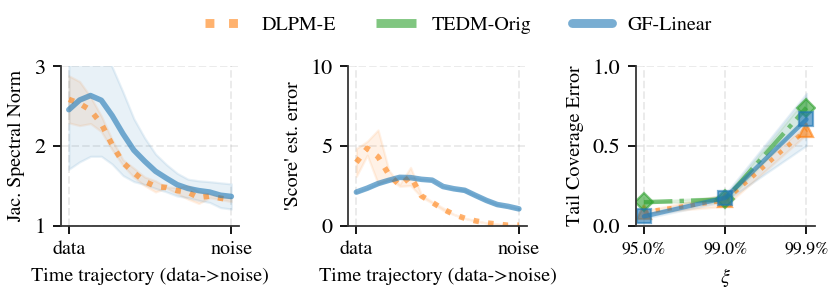

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(6.2, 2.0), squeeze=False)

inspect_curve_len = max(first_curve_length(jacobian_runs), first_curve_length(err_t_runs))

for spec in model_specs:
    if jacobian_runs[spec["name"]]:
        values_jacobian_runs = np.stack(jacobian_runs[spec["name"]], axis=0)
        plot_band(axes[0, 0], values_jacobian_runs.mean(axis=0), values_jacobian_runs.std(axis=0), color=source_colors[spec["name"]], linestyle=spec["linestyle"], lw=2.5, alpha=0.6, fill_alpha=0.1, label=spec["name"], lower_clip=1e-12)

    if err_t_runs[spec["name"]]:
        values_err_t_runs = np.stack(err_t_runs[spec["name"]], axis=0)
        plot_band(axes[0, 1], values_err_t_runs.mean(axis=0), values_err_t_runs.std(axis=0), color=source_colors[spec["name"]], linestyle=spec["linestyle"], lw=2.5, alpha=0.6, fill_alpha=0.1, label=spec["name"], lower_clip=1e-12)

    values_tail_error = np.stack([np.asarray(curve["tail_error"], dtype=float) for curve in tail_curves if curve["model"] == spec["name"]], axis=0)
    plot_band(axes[0, 2], values_tail_error.mean(axis=0), values_tail_error.std(axis=0), color=source_colors[spec["name"]], linestyle=spec["linestyle"], lw=2.0, alpha=0.6, fill_alpha=0.1, label=spec["name"], marker=spec["marker"])

axes[0, 0].set_ylim(1, 3)
if inspect_curve_len > 0:
    axes[0, 0].set_xticks([0, inspect_curve_len - 1], ["data", "noise"], fontsize=9)
axes[0, 0].set_ylabel("Jac. Spectral Norm", fontsize=9)
axes[0, 0].set_xlabel("Time trajectory (data->noise)", fontsize=9)

axes[0, 1].set_ylim(0, 10)
if inspect_curve_len > 0:
    axes[0, 1].set_xticks([0, inspect_curve_len - 1], ["data", "noise"], fontsize=9)
axes[0, 1].set_ylabel("'Score' est. error", fontsize=9)
axes[0, 1].set_xlabel("Time trajectory (data->noise)", fontsize=9)

axes[0, 2].set_ylim(0, 1)
axes[0, 2].set_xticks(np.arange(values_tail_error.shape[1]), [f"{xi:.1%}" for xi in tail_metric_grid], fontsize=8)
axes[0, 2].set_xlabel(r"$\xi$", fontsize=9)
axes[0, 2].set_ylabel("Tail Coverage Error", fontsize=9)

legend_handles =  [Line2D([0], [0], color=source_colors[spec["name"]], lw=4.0, linestyle=spec["linestyle"], label=spec["name"], alpha=0.6) for spec in model_specs]
fig.legend(legend_handles, [handle.get_label() for handle in legend_handles], loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0, 0.9, 0.9))

plt.savefig(figures_dir / "inspect_curves.png", dpi=300)
plt.show()


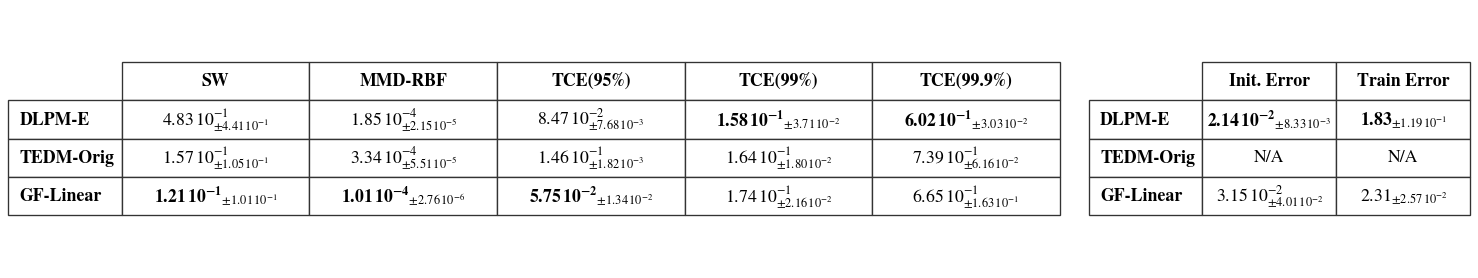

In [9]:
metrics_table = formatted.rename(columns={"SW2": "Sliced-W2", "MMD_RBF": "MMD-RBF", "TCE_95": "TCE(95)", "TCE_99": "TCE(99)", "TCE_999": "TCE(999)"})
inspect_metric_specs = {"Init. Error": "err_init", "Train Error": "err_train"}
inspect_columns = {}
for column_name, metric_name in inspect_metric_specs.items():
    valid_models = [model_name for model_name in source_order if np.isfinite(inspect_summary.loc[model_name, metric_name]["mean"])]
    best_model = None if not valid_models else min(valid_models, key=lambda model_name: max(0.0, inspect_summary.loc[model_name, metric_name]["mean"]))
    inspect_columns[column_name] = [format_mean_std_or_na(inspect_summary.loc[model_name, metric_name], bold=model_name == best_model)
                                    for model_name in source_order]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 2.0), gridspec_kw={"width_ratios": [3.5, 1]}, squeeze=False)

render_dataframe_table(axes[0, 0], metrics_table, fontsize=8, scale=(1.0, 1.35))
render_dataframe_table(axes[0, 1], pd.DataFrame(inspect_columns, index=source_order), fontsize=8, scale=(1.0, 1.35))

fig.tight_layout()

plt.savefig(figures_dir / "tables.png", dpi=300)
plt.show()

